# Epidemic likelihoods 1 - theory and derivations

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gem-epidemics/colab/blob/master/iddinf/epidemic_likelihoods_1.ipynb)

In this session, we expand on the previous material by looking at likelihood functions for epidemic models.

## Learning outcomes
- Mathematical specification of likelihood functions for (continuous and discrete time) epidemic models
- Time slicing likelihood formulation
- Iterative implemenation of evaluation
- Maximum likelihood parameter estimation for simulated data



---

## Theory

Epidemic models belong to a broader class of models called *state transition* models where units are categorized into a finite set of model states. These models aim to describe the progression of an underlying epidemic process. State transition models are used in other research areas as well such as queuing theory, clinical trails history, and reliability engineering.

Epidemic processes are naturally counting processes since the main object of interest is the number of units that are in each model state. Mathematically, these types of processes are known as *Poisson processes*. We define a Poisson process over a fixed time period $[0, t_{max})$ during which we are counting the number of events that occur. There are several important properties about these processes that help with formulating the likelihood.

1. **Independence** The number of events that occur in disjoint intervals of time are independent. For example, if we partition the time period into $[0, \frac{t_{max} }{ 2 }) \cup [\frac{t_{max} }{ 2 }, t_{max})$, the number of events occurring in each subset is independent of the other.
2. **Exponential wait times** The waiting time between consecutive events in a Poisson process follows an exponential distribution. This means the waiting time until the next event is memoryless, and the likelihood of an event occurring soon after the previous event is the same as if we had just started observing.
3. **Stationarity** The probability of an event occuring in a time interval depends only on the length of the time interval. In other words, we assume that the event rate $\lambda$ is constant over a time interval.

The stationarity condition might initially seem strong, but it does help distinguish between two types of Poisson processes. The first is a time *homogeneous process* where the event rate $\lambda$ is constant over time. The second is a time *inhomogeneous process* where the event rate $\lambda(t)$ varies over time. We make this clear by indicating $\lambda(t)$ is a function of time (and not a constant).

Epidemic models such as the SIR model are great examples of a time inhomogeneous Poisson process. The event rates often depend on the number of units in each state of the model (eg. frequency or density dependent transmission rate functions). This means that as units transition between states, the event rates will change accordingly making this an inhomogeneous process.



## Likelihood function of the SIR model
Suppose we define a Susceptible-Infected-Removed model graphically as shown below.

```{mermaid}
:name: sir-model
:alt: Diagram of the SIR state transition model
:caption: The SIR state transition model

---
config:
  look: handDrawn
  theme: neutral
---

graph LR
  S:::green -->|"$$\lambda^{SI}(t, X_t)$$"| I:::red
  I:::red -->|"$$\lambda^{IR}(t, X_t)$$"| R:::lilac

  classDef green fill:#d9fcd1
  classDef red fill:#f4cecd
  classDef lilac fill:#cdcdfb
  
```

In this model, there are two transition events that can occur.

1. $S → I$ - infection event
2. $I → R$ - removal event

Each of these is itself a time inhomogeneous Poisson process which makes the SIR model a time inhomogeneous Poisson process (the sum of Poisson processes is itself a Poisson process - proof can be done with moment generating function but not important for this course). To write out the likelihood function, we take advantage of the independence property and exponentially distributed wait times property.

Suppose that observations (or data) are over a time period $[0 ,t_{max})$ as before. We can partition this period into smaller (left closed-right open) intervals such that each interval contains *only* 1 event. Set the length of each interval as $\delta t_i= t_{s+1}- t_s$ and then
\begin{equation}
[0 ,t_{max}) = \bigcup_{s \in = 0,\ldots, max-1} [t_s, t_{s+1})
\end{equation}
Recall that in each time interval, the wait time until the next event is exponentially distributed with a constant rate. For SIR model, we define the infection rate as $\lambda^{SI}(t)$ and the removal rate as $\lambda^{IR}(t)$. Let $z^{SI}, z^{IR}$ be the number of infection and removal events respectively since time $t=0$. Then, for any time interval, the probability of observing each event is
\begin{align}
\delta_{t_s}^{SI}&\sim \mbox{Exponential}(\lambda^{SI}(t_s)) \\
\delta_{t_s}^{IR}&\sim \mbox{Exponential}(\lambda^{IR}(t_s)) \\
\Rightarrow P(z^{SI}_{t_s + \delta t_s} - z^{SI}_{t_s} = 1 | z^{SI}_{t_s}) &= 1 -  e^{-\lambda^{SI}(t_s)\delta_{t_s}} \\
\Rightarrow P(z^{IR}_{t_s + \delta t_s} - z^{IR}_{t_s} = 1 | z^{IR}_{t_s}) &= 1 -  e^{-\lambda^{IR}(t_s)\delta_{t_s}}
\end{align}
In contrast, the probability that an event did *not* occur in that time window can be evaluated with the accompanying survival function.
\begin{align}
P(z^{SI}_{t_s + \delta t_s} - z^{SI}_{t_s} = 0) &= e^{-\lambda^{SI}(t_s)\delta t_s} \\
P(z^{IR}_{t_s + \delta t_s} - z^{IR}_{t_s} = 0) &= e^{-\lambda^{IR}(t_s)\delta t_s}
\end{align}
Therefore, the likelihood that an infection event occured in a time interval is
\begin{align}
P(S \rightarrow I, \delta t_s| H_t) &= \lambda^{SI}(t_s) e^{-\lambda^{SI}(t_i) \delta t_s} e^{-\lambda^{IR}(t_i) \delta t_s} \\
&= \lambda^{SI}(t_s) e^{ - \left(\lambda^{SI}(t_i)+\lambda^{IR}(t_s)\right)\delta t_s}
\end{align}
Similarly for the likeihood of a removal event
\begin{align}
P(I \rightarrow R, \delta t_s| H_t) &= \lambda^{IR}(t_s) e^{-\lambda^{IR}(t_s) \delta t_s} e^{-\lambda^{SI}(t_s) \delta t_s} \\
&= \lambda^{IR}(t_s) e^{ -\left(\lambda^{SI}(t_s)+\lambda^{IR}(t_s)\right) \delta t_s}
\end{align}
Since each time interval is independent of the other, we can get the likelihood of the entire process by taking the product over all time intervals
\begin{equation}
L(X|H) = \prod_{s=0}^{max - 1} \lambda(t_s) e^{ -\left(\lambda^{SI}(t_s)+\lambda^{IR}(t_s)\right) \delta t_s}
\end{equation}
\begin{equation}
l(X|H) = \sum_{s=0}^{max - 1} \log\lambda(t_s) - \sum_{s=0}^{max - 1}\left(\lambda^{SI}(t_s)+\lambda^{IR}(t_s)\right) \delta t_s
\end{equation}
For convenience, we drop the superscript on the event occurred (the $\lambda (t)$ which is not part of the expontential because it is clear that it indicates the rate of the transition event that occurred.

### Exercise 
````{exercise-start}
:label: ex4.1
````

Consider the data generated by SIR model with following transition rates.

\begin{equation}
\left\{\begin{array}{lr}
        \lambda^{SI} (t) = 0.005 S(t)I(t) & \mbox{infectious pressure in system}\\
        \lambda^{IR}_i (t) = 0.02 I(t) & \mbox{removal pressure in system} \\
        0 & \text{o.w.}
        \end{array}\right.
\end{equation}

In [125]:
import jax
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

In [126]:
unit_id = np.arange(0, 3)
infection_times = np.array([0.0, 4.0, 2.0])
removal_times = np.array([3.0, 6.0, 8.0])

ex1_data = pd.DataFrame(
    {
        "unit_id": unit_id,
        "infection_time": infection_times,
        "removal_time": removal_times,
    }
)
ex1_data

,unit_id,infection_time,removal_time
0,0,0.0,3.0
1,1,4.0,6.0
2,2,2.0,8.0


In [127]:
# convert to array for plotting
ex1_data = np.array(ex1_data)

[]

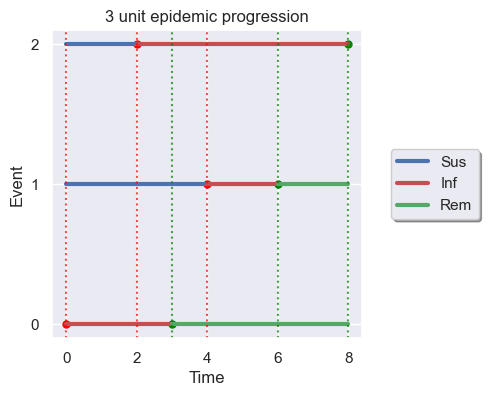

In [128]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

pop_size = 3

fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot()

ax.scatter(ex1_data[:, 1], ex1_data[:, 0], color="red", s=25)
ax.scatter(ex1_data[:, 2], ex1_data[:, 0], color="green", s=25)

plt.yticks(np.arange(pop_size))

# plot susceptible period
for ii in range(pop_size):
    x = [0, ex1_data[ii, 1]]
    y = [ii, ii]
    ax.plot(x, y, "b-", alpha=1, linewidth=3, label="Sus")

# plot infective period
for ii in range(pop_size):
    x = [ex1_data[ii, 1], ex1_data[ii, 2]]
    y = [ii, ii]
    ax.plot(x, y, "r-", alpha=1, linewidth=3, label="Inf")
    # ax.text(x, y, f" {ii}", color='red')

# plot removed period
for ii in range(pop_size):
    x = [ex1_data[ii, 2], np.max(ex1_data[:, 2])]
    y = [ii, ii]
    ax.plot(x, y, "g-", alpha=1, linewidth=3, label="Rem")
    # ax.text(x, y, f" {ii}", color='red')

legend_elements = [
    Line2D([0], [0], color="b", lw=3, label="Sus"),
    Line2D([0], [0], color="r", lw=3, label="Inf"),
    Line2D([0], [0], color="g", lw=3, label="Rem"),
]

# plot horizontal dashed lines at each event
for ii in range(pop_size):
    plt.axvline(x=ex1_data[ii, 1], linestyle="dotted", color="red", alpha=0.7)
    plt.axvline(x=ex1_data[ii, 2], linestyle="dotted", color="green", alpha=0.7)

plt.xlabel("Time")
plt.ylabel("Event")
plt.title(f"{pop_size} unit epidemic progression")

plt.legend(
    handles=legend_elements,
    loc="right",
    bbox_to_anchor=(1.4, 0.5),
    ncol=1,
    fancybox=True,
    shadow=True,
)
ax.plot()

__Question__

Compute the log-likelihood of the first event (i.e. unit 2 undergoing an infection event) occuring after the first time-slice.

````{exercise-end}
````

````{solution-start} ex4.1
:class: dropdown
````


At $t=0$, there is 1 infected unit and 2 susceptible units. We can then compute the transition rates for each of unit.

In [129]:
# constants
beta = 0.005
gamma = 0.02

S_0 = 2
I_0 = 1
R_0 = 0


def transition_rate_fn(S, I, R):
    # si rate
    si_rate = beta * S * I
    # ir rate
    ir_rate = gamma * I
    return si_rate, ir_rate


# transition rates
transition_rates = transition_rate_fn(S_0, I_0, R_0)

# time delta
delta_t = 2.0 - 0

In [130]:
delta_t

2.0

In [131]:
# likelihood follows from L(X|D) formula
print(
    f"L(X|D) = {transition_rates[0] * np.exp(-np.sum(transition_rates)) * int(delta_t)}"
)
print(
    f"log L(X|D) = {np.log(transition_rates[0] * np.exp(-np.sum(transition_rates)) * delta_t)}"
)

L(X|D) = 0.019408910670970163
log L(X|D) = -3.942023005428146


````{solution-end}
````


## Data frame computation 

Computing the log-likelihood of the whole process in a data frame centric manner. 


One way to do this is to create a dataframe with all of the values we need. Lets break up the problem into some smaller steps

1. Check the likelihood formula to see what values we need
2. Create a dataframe with the raw data
3. Compute the transition rates for each time step
4. Identify the event which occurs
5. Compute the likelihood
6. Evaluate the likelihood and log-likelihood

In [132]:
# create a data frame of the counts at each time step
time_steps = np.sort(np.concatenate([infection_times, removal_times]))
num_S = np.array([2, 1, 1, 0, 0, 0])
num_I = np.array([1, 2, 1, 2, 1, 0])
num_R = np.array([0, 0, 1, 1, 2, 3])


In [133]:
# need total counts for the transition rates so create a dataframe
epidemic_data = pd.DataFrame(
    np.stack([time_steps, num_S, num_I, num_R], axis=-1),
    columns=["time", "S", "I", "R"],
)

epidemic_data

,time,S,I,R
0,0.0,2.0,1.0,0.0
1,2.0,1.0,2.0,0.0
2,3.0,1.0,1.0,1.0
3,4.0,0.0,2.0,1.0
4,6.0,0.0,1.0,2.0
5,8.0,0.0,0.0,3.0


In [134]:
# add which event happened
# convention: 0 - infection, 1 - removal, 2 - null/non event
epidemic_data["event_type"] = np.array([0, 0, 1, 1, 1, 2])
epidemic_data

,time,S,I,R,event_type
0,0.0,2.0,1.0,0.0,0
1,2.0,1.0,2.0,0.0,0
2,3.0,1.0,1.0,1.0,1
3,4.0,0.0,2.0,1.0,1
4,6.0,0.0,1.0,2.0,1
5,8.0,0.0,0.0,3.0,2


In [135]:
# compute rates for each event as a new column


def transition_rates(row):
    # infection event
    if row.event_type == 0:
        return beta * row.S * row.I
    # removal event
    elif row.event_type == 1:
        return gamma * row.I
    # otherwise
    else:
        return 0


epidemic_data = epidemic_data.assign(
    # compute all event rates
    si_rate=beta * epidemic_data.S * epidemic_data.I,
    ir_rate=gamma * epidemic_data.I,
    # apply the transiton_rates fn to each row
    event_occured_rate=lambda df: df.apply(transition_rates, axis=1),
)

epidemic_data

,time,S,I,R,event_type,si_rate,ir_rate,event_occured_rate
0,0.0,2.0,1.0,0.0,0,0.010,0.02,0.01
1,2.0,1.0,2.0,0.0,0,0.010,0.04,0.01
2,3.0,1.0,1.0,1.0,1,0.005,0.02,0.02
3,4.0,0.0,2.0,1.0,1,0.000,0.04,0.04
4,6.0,0.0,1.0,2.0,1,0.000,0.02,0.02
5,8.0,0.0,0.0,3.0,2,0.000,0.00,0.00


In [136]:
# compute time deltas
epidemic_data["time_delta"] = -epidemic_data.time.diff(-1)
epidemic_data

,time,S,I,R,event_type,si_rate,ir_rate,event_occured_rate,time_delta
0,0.0,2.0,1.0,0.0,0,0.010,0.02,0.01,2.0
1,2.0,1.0,2.0,0.0,0,0.010,0.04,0.01,1.0
2,3.0,1.0,1.0,1.0,1,0.005,0.02,0.02,1.0
3,4.0,0.0,2.0,1.0,1,0.000,0.04,0.04,2.0
4,6.0,0.0,1.0,2.0,1,0.000,0.02,0.02,2.0
5,8.0,0.0,0.0,3.0,2,0.000,0.00,0.00,NaN


In [137]:
# Compute the likelihoods - use lambda function
def likelihood(row):
    return row.event_occured_rate * np.exp(
        -(row.si_rate + row.ir_rate) * row.time_delta
    )


epidemic_data["lik_t"] = epidemic_data.apply(likelihood, axis=1)

epidemic_data

,time,S,I,R,event_type,si_rate,ir_rate,event_occured_rate,time_delta,lik_t
0,0.0,2.0,1.0,0.0,0,0.010,0.02,0.01,2.0,0.009418
1,2.0,1.0,2.0,0.0,0,0.010,0.04,0.01,1.0,0.009512
2,3.0,1.0,1.0,1.0,1,0.005,0.02,0.02,1.0,0.019506
3,4.0,0.0,2.0,1.0,1,0.000,0.04,0.04,2.0,0.036925
4,6.0,0.0,1.0,2.0,1,0.000,0.02,0.02,2.0,0.019216
5,8.0,0.0,0.0,3.0,2,0.000,0.00,0.00,NaN,NaN


In [138]:
print(f"L(X|D) = {epidemic_data.lik_t[:-1].prod()}")
print(f"log L(X|D) = {np.log(epidemic_data.lik_t[:-1].prod())}")

L(X|D) = 1.2398663967377296e-09
log L(X|D) = -20.508262207700675


## Array computation (numpy)

The pandas workflow above builds up a table one column at a time, using row-wise iteration through the  `.apply` data frame method and  `lambda` function calls. This is easy to read and expressive, but it is slow for large datasets. Instead, we will use `numpy` arrays and take advantage of vectorized operations to do the calculation.

In [139]:
# Step 1 - raw data as plain numpy arrays (no DataFrame)
time = np.array([0.0, 2.0, 3.0, 4.0, 6.0, 8.0])
S = np.array([2.0, 1.0, 1.0, 0.0, 0.0, 0.0])
I = np.array([1.0, 2.0, 1.0, 2.0, 1.0, 0.0])
R = np.array([0.0, 0.0, 1.0, 1.0, 2.0, 3.0])

# convention: 0 - infection, 1 - removal, 2 - null/non event
event_type = np.array([0, 0, 1, 1, 1, 2])

time

array([0., 2., 3., 4., 6., 8.])

In [140]:
# Step 2 - vectorised transition rates for every time step at once
# (equivalent to epidemic_data.assign(si_rate=..., ir_rate=...) above)
si_rate, ir_rate = transition_rate_fn(S, I, R)

print(f"S->I rates: {si_rate}")
print(f"I->R rates: {ir_rate}")

S->I rates: [0.01  0.01  0.005 0.    0.    0.   ]
I->R rates: [0.02 0.04 0.02 0.04 0.02 0.  ]


In [141]:
# Step 3 - rate of whichever event actually occurred, using boolean masks
event_occured_rate = np.zeros_like(time)
print(f"Initial event_occured_rate: {event_occured_rate}")

infection_mask = event_type == 0
removal_mask = event_type == 1
# event_type == 2 (no event) leaves the rate at 0, hence np.zeros_like

event_occured_rate[infection_mask] = si_rate[infection_mask]
print(f"Intermediate event_occured_rate: {event_occured_rate}")
event_occured_rate[removal_mask] = ir_rate[removal_mask]
print(f"Final event_occured_rate: {event_occured_rate}")


Initial event_occured_rate: [0. 0. 0. 0. 0. 0.]
Intermediate event_occured_rate: [0.01 0.01 0.   0.   0.   0.  ]
Final event_occured_rate: [0.01 0.01 0.02 0.04 0.02 0.  ]


In [142]:
# Step 4 - time deltas with np.diff
time_delta = np.diff(time)
time_delta = np.append(time_delta, np.nan)

time_delta

array([ 2.,  1.,  1.,  2.,  2., nan])

In [143]:
# Step 5 - per-interval likelihood, fully vectorised
lik_t = event_occured_rate * np.exp(-(si_rate + ir_rate) * time_delta)

lik_t

array([0.00941765, 0.00951229, 0.0195062 , 0.03692465, 0.01921579,
              nan])

In [144]:
# Step 6 - likelihood and log-likelihood
L = np.prod(lik_t[:-1])
logL = np.sum(
    np.log(event_occured_rate[:-1]) - (si_rate[:-1] + ir_rate[:-1]) * time_delta[:-1]
)

print(f"L(X|D) = {L}")
print(f"log L(X|D) = {logL}")

# sanity check: log of the product should match the summed log-likelihood
print(f"log(L) = {np.log(L)}")

L(X|D) = 1.2398663967377296e-09
log L(X|D) = -20.508262207700675
log(L) = -20.508262207700675


In [145]:
# Optional - combine into a single 2D array and rebuild data frame
epidemic_array = np.column_stack(
    [time, S, I, R, event_type, si_rate, ir_rate, event_occured_rate, time_delta, lik_t]
)

pd.DataFrame(epidemic_array, columns=epidemic_data.columns)

,time,S,I,R,event_type,si_rate,ir_rate,event_occured_rate,time_delta,lik_t
0,0.0,2.0,1.0,0.0,0.0,0.010,0.02,0.01,2.0,0.009418
1,2.0,1.0,2.0,0.0,0.0,0.010,0.04,0.01,1.0,0.009512
2,3.0,1.0,1.0,1.0,1.0,0.005,0.02,0.02,1.0,0.019506
3,4.0,0.0,2.0,1.0,1.0,0.000,0.04,0.04,2.0,0.036925
4,6.0,0.0,1.0,2.0,1.0,0.000,0.02,0.02,2.0,0.019216
5,8.0,0.0,0.0,3.0,2.0,0.000,0.00,0.00,NaN,NaN


Both approaches give the same result: $L(X\mid H) \approx 1.24\times10^{-9}$ and $\log L(X\mid H) \approx -20.51$, matching the pandas computation above.

The array version avoids `.apply` entirely and instead vectorises over the whole array of time steps at once, which is substantially faster for larger datasets. Conveniently, you can also swap in `jax.numpy` which gives you automatic differentiation. Auto-diff can be used by optimization algorithms for computing gradients of the log-likelihood (with respect to `beta` and `gamma`) so we can do maximum likelihood estimation

## Generalizing the formula
State transition models can become complex quickly with the introduction of new states or different population structures. The fomula above can easily be generalized to account for such changes. Let $\lambda_{j}^{qr}(t_i)$ be the rate of transitioning from compartment $q$ to $r$ at time $t_i$ for subgroup $j$. The probabilities of observing, or not observing, a $qr$ event are

\begin{align}
\delta_{t_s}^{qr} &\sim \mbox{Exponential} (\lambda_j^{qr}(t_s)) \\
P(z^{qr}_{t_s + \delta_{t_s}^{qr}} - z^{qr}_{t_s} = 1| \delta_{t_s}^{qr}) &= 1 - e^{-\lambda_j^{qr}(t_s) \delta_{t_s}^{qr}} \\
P(z^{qr}_{t_s + \delta_{t_s}^{qr}} - z^{qr}_{t_s} = 0| \delta_{t_s}^{qr}) &= e^{-\lambda_j^{qr}(t_s)\delta_{t_s}^{qr}} \\
\Rightarrow L(X|H) &= \prod_{s=0}^{max - 1} \left[\lambda_j^{qr}(t_s) \exp(-\lambda_j^{qr}(t_s)  \delta_{t_s}^{qr}) \right]^{\mathbb{I}_{t_s}^{qr}} \left[ \exp(-\lambda_j^{qr}(t_s)  \delta_{t_s}^{qr})  \right]^{1- \mathbb{I}_{t_s}^{qr}}
\end{align}

Where $\mathbb{I}_{t_s}^{qr}$ is the indicator function of a $qr$ event for group $i$ in interval $t_s$.

It is worth noting that this example _is_ a continuous time model. In practice, we often prefer to aggregate events into set time intervals (eg. 1 day, 1 week, etc).


## Aggregating events

Another way to partition the observation period of an epidemic is into blocks of fixed lengths. In doing so, every unit in the population undergoes an Bernoulli experiment in each time period to see if they undergo an event or they "survive" the period. This was briefly covered in the [epidemic modelling refresher](https://gem-epidemics.gitlab.io/practical-epidemics/iddinf/epi_refresher.html) session.

Recall that for the SIR model with transition events $S\rightarrow I$ and $I \rightarrow R$ we get the following probabilites of surviving a time interval $\delta t_i$
\begin{align*}
p^{SI}_{t_s}&=1-e^{-\lambda^{SI}(t_s)\delta t_s} \\
p^{IR}_{t_s}&=1-e^{-\lambda^{IR}(t_s)\delta t_s}
\end{align*}
Since there are $S$-many susceptible units and $I$-many infected units, we are taking the sum of $S$ and $I$ many Bernoulli experiments which follows a binomial distribution. This is known as the **chain binomial model**.

\begin{align*}
z_{t_s}^{SI} &\sim \mbox{Binomial}(S_{t_s}, p^{SI}_{t_s}) \\
z_{t_s}^{IR} &\sim \mbox{Binomial}(I_{t_s}, p^{IR}_{t_s})
\end{align*}

Here, we have two coinciding binomial random variables in the same time period which are independent of each other. The likelihood function for this model is then
\begin{equation}
L(X|H) = \prod_{s = 0}^{max - 1} \binom{S_{t_s}}{k} \left(p^{SI}_{t_s} \right)^k \left(1-p^{SI}_{t_s} \right)^{S_{t_s}-k} \cdot \binom{ I_{t_s}}{j} \left(p^{IR}_{t_s} \right)^j \left(1-p^{IR}_{t_s} \right)^{I_{t_s}-j}
\end{equation}

\begin{equation}
l(X|H) \propto \sum_{s = 0}^{max - 1}\left( k \log p^{SI}_{t_s} + (S_{t_s}-k)\log(1-p^{SI}_{t_s}) + j \log p^{IR}_{t_s} + (I_{t_s}-j)\log(1-p^{IR}_{t_s}) \right)
\end{equation}